# 資料前處理
由於 KNN impute 會比較花時間，可以跳到後面直接載入 parquet 檔案

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/Health_Dataset/health_dataset.csv")
df.drop(columns=[
    "ADM_RNO1",  # administrative record number
    "Province",  # province where the respondent resides
    "Health_region_ grouped",
], inplace=True)
df.columns

Index(['Gender', 'Marital_status', 'Household', 'Age', 'Worked_job_business',
       'Edu_level', 'Gen_health_state', 'Life_satisfaction',
       'Mental_health_state', 'Stress_level', 'Work_stress', 'Sense_belonging',
       'Weight_state', 'BMI_12_17', 'BMI_18_above', 'Sleep_apnea', 'High_BP',
       'High_cholestrol', 'Diabetic', 'Fatigue_syndrome', 'Mood_disorder',
       'Anxiety_disorder', 'Respiratory_chronic_con', 'Musculoskeletal_con',
       'Cardiovascular_con', 'Health_utility_indx', 'Pain_status',
       'Act_improve_health', 'Fruit_veg_con', 'Smoked', 'Tobaco_use',
       'weekly_alcohol', 'Cannabies_use', 'Drug_use', 'Total_active_time',
       'Total_physical_act_time', 'Other_physical_act_time',
       'Physical_vigorous_act_time', 'Work_hours ', 'working_status ',
       'Aboriginal_identity', 'Birth_country', 'Immigrant', 'Insurance_cover',
       'Food_security', 'Income_source', 'Total_income'],
      dtype='object')

In [ ]:
# Life_satisfaction的97,98,99均無效
df.replace({"Life_satisfaction": [97,98,99]}, np.nan, inplace=True)
# 移除 life_satisfaction 缺漏的row
df.dropna(subset=["Life_satisfaction"], inplace=True)
# 在Worked_job_business中，6,7,8,9其實都算是無效輸入，合併為9
df.replace({"Worked_job_business": [6,7,8,9]}, 9, inplace=True)
# 合併Gen_health_state的6,9
df.replace({"Gen_health_state": [6,9]}, np.nan, inplace=True)
# 合併Mental_health_state的7,8,9
df.replace({"Mental_health_state": [7,8,9]}, np.nan, inplace=True)
# 合併Stress_level的7,8
df.replace({"Stress_level": [7,8]}, np.nan, inplace=True)
# 合併Work_stress的6,7,8,9
df.replace({"Work_stress": [6,7,8,9]}, np.nan, inplace=True)
# 合併Sense_belonging的7,8,9
df.replace({"Sense_belonging": [7,8,9]}, np.nan, inplace=True)
# 合併Weight_state的6,7,8,9
df.replace({"Weight_state": [6,7,8,9]}, 9, inplace=True)
# 合併BMI欄位。一邊6另一邊就會是9，並且一題回答另一邊就會是6
def merge_bmi(row):
    if row["BMI_12_17"] == 9 or row["BMI_18_above"] == 9:
        return 9
    elif row["BMI_12_17"] in [1, 2] or row["BMI_18_above"] in [1, 2]:
        # 如果有一邊是 1 或 2，則設為相對應的值
        return row["BMI_12_17"] if row["BMI_12_17"] in [1, 2] else row["BMI_18_above"]
    else:
        # 如果有任何其他情況，報錯
        raise ValueError(f"Invalid BMI values: {row['BMI_12_17']}, {row['BMI_18_above']}")
df["BMI"] = df.apply(merge_bmi, axis=1)
df.drop(columns=["BMI_12_17", "BMI_18_above"], inplace=True)
# 合併Sleep_apnea的7,8
df.replace({"Sleep_apnea": [7,8]}, 8, inplace=True)
# 合併High_BP的7,8
df.replace({"High_BP": [7,8]}, 8, inplace=True)
# 合併High_cholestrol的6,7,8
df.replace({"High_cholestrol": [6,7,8]}, 8, inplace=True)
# 合併Diabetic的6,7,8
df.replace({"Diabetic": [6,7,8]}, 8, inplace=True)
# 合併Fatigue_syndrome的7,8
df.replace({"Fatigue_syndrome": [7,8]}, 8, inplace=True)
# 合併Mood_disorder的7,8
df.replace({"Mood_disorder": [7,8]}, 8, inplace=True)
# 合併 Anxiety_disorder 的7,8
df.replace({"Anxiety_disorder": [7,8]}, 8, inplace=True)
# 合併 Musculoskeletal_con 的6,9
df.replace({"Musculoskeletal_con": [6,9]}, 9, inplace=True)
# 合併 Act_improve_health 的6,7,8
df.replace({"Act_improve_health": [6,7,8]}, 8, inplace=True)
# 合併 Fruit_veg_con 的6,9
df.replace({"Fruit_veg_con": [6,9]}, np.nan, inplace=True)
# 只考慮有沒有抽菸。沒有人有 Smoked 但是 Tobaco_use 是 2(No)
df.drop(columns=["Smoked"], inplace=True)
df.replace({"Tobaco_use": [6,7,8,9]}, 9, inplace=True)
# 合併 weekly_alcohol 的6,7,8,9
df.replace({"weekly_alcohol": [6,7,8,9]}, 9, inplace=True)
# 合併 Cannabies_use 的6,7,8,9
df.replace({"Cannabies_use": [6,7,8,9]}, 9, inplace=True)
# 合併 Drug_use 的3,4
df.replace({"Drug_use": [3,4]}, 4, inplace=True)
# Total_active_time 的99996~99999全部無效
df.replace({"Total_active_time": [9996,9997,9998,9999]}, np.nan, inplace=True)
# Total_physical_act_time 的99996~99999全部無效
df.replace({"Total_physical_act_time": [9996,9997,9998,9999]}, np.nan, inplace=True)
# Physical_vigorous_act_time 的99996,99999無效
df.replace({"Physical_vigorous_act_time": [9996,9999]}, np.nan, inplace=True)
# Work_hours 的96,99無效
df.replace({"Work_hours ": [96,99]}, np.nan, inplace=True)
# 合併 working_status 的6,9
df.replace({"working_status ": [6,9]}, 9, inplace=True)
# 合併 Aboriginal_identity 的7,8,9
df.replace({"Aboriginal_identity": [7,8,9]}, 9, inplace=True)
# 合併 Food_security 的6,9
df.replace({"Food_security": [6,9]}, np.nan, inplace=True)

numeric_columns = [
    "Edu_level",
    "Gen_health_state",
    "Mental_health_state",
    "Stress_level",
    "Work_stress",
    "Sense_belonging",
    "Total_active_time",
    "Total_physical_act_time",
    "Other_physical_act_time",
    "Physical_vigorous_act_time",
    "Food_security",
    "Fruit_veg_con",
    "Total_income",
]

one_hot_columns = [
    "Gender",
    "Marital_status",
    "Household",
    "Age",
    "Worked_job_business",
    # "Life_satisfaction",
    "Weight_state",
    "BMI",
    "Sleep_apnea",
    "High_BP",
    "High_cholestrol",
    "Diabetic",
    "Fatigue_syndrome",
    "Mood_disorder",
    "Anxiety_disorder",
    "Respiratory_chronic_con",
    "Musculoskeletal_con",
    "Cardiovascular_con",
    "Health_utility_indx",
    "Pain_status",
    "Act_improve_health",
    "Tobaco_use",
    "weekly_alcohol",
    "Cannabies_use",
    "Drug_use",
    "Work_hours ",
    "working_status ",
    "Aboriginal_identity",
    "Birth_country",
    "Immigrant",
    "Insurance_cover",
    "Income_source",
]

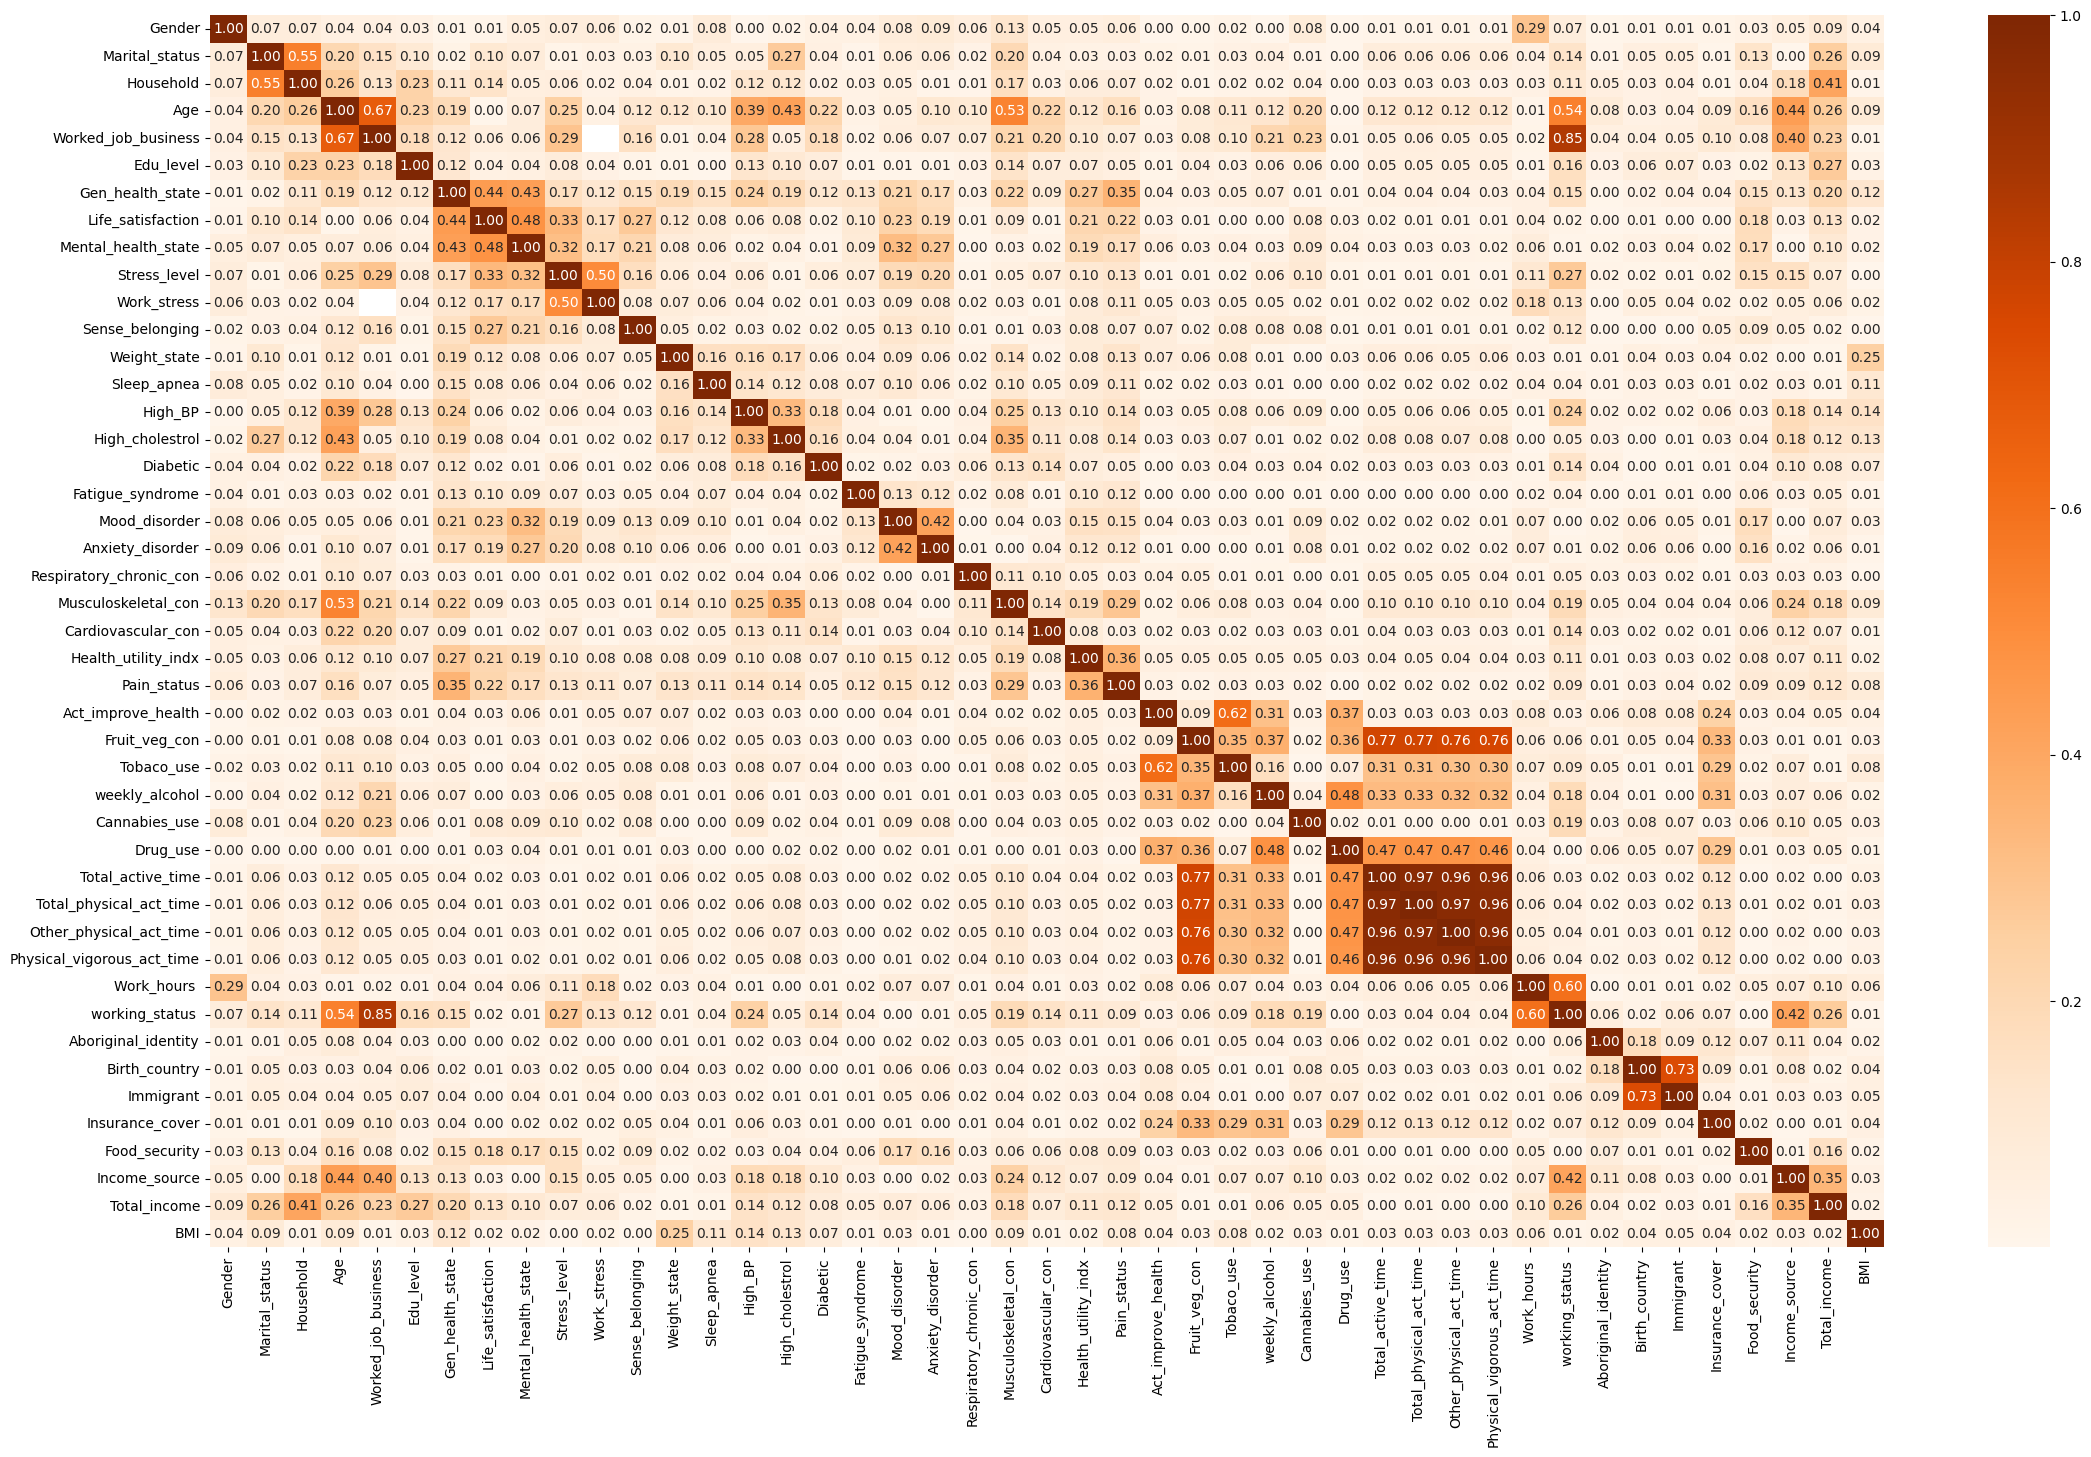

In [3]:
import seaborn as sns

plt.figure(figsize=(27, 16))
corr_matrix = df.corr(method='spearman').abs()
sns.heatmap(corr_matrix, annot=True, cmap='Oranges', fmt=".2f")
plt.show()

In [4]:
df = pd.get_dummies(df, drop_first=True, columns=one_hot_columns)

In [5]:
try:
    from sklearnex import patch_sklearn, config_context
    patch_sklearn()
except ImportError: pass
from contextlib import nullcontext
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

imputer = KNNImputer(n_neighbors=5, weights="distance")

df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

scaler = StandardScaler()

with config_context(target_offload="auto") if 'config_context' in globals() else nullcontext():
    df[numeric_columns] = scaler.fit_transform(df[numeric_columns])
df

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


,Edu_level,Gen_health_state,Life_satisfaction,Mental_health_state,Stress_level,Work_stress,Sense_belonging,Fruit_veg_con,Total_active_time,Total_physical_act_time,...,Birth_country_9,Immigrant_2,Immigrant_9,Insurance_cover_2,Insurance_cover_6,Insurance_cover_7,Insurance_cover_8,Insurance_cover_9,Income_source_2,Income_source_9
0,-0.000906,0.563802,9.0,0.881354,-0.565478,-0.939196,-0.127853,-1.745466,-2.086782,-2.082262,...,False,True,False,False,False,False,False,False,False,False
1,-0.646272,0.563802,4.0,0.881354,0.417423,0.755871,1.097969,-1.745536,-2.086782,-2.082262,...,False,True,False,False,False,False,False,False,True,False
2,-1.291639,-0.394318,7.0,0.881354,0.417423,-0.939196,-0.127853,0.573395,0.484533,0.485451,...,False,True,False,False,True,False,False,False,True,False
3,-1.291639,0.563802,8.0,0.881354,0.417423,0.008524,-0.127853,0.573395,0.484533,0.485451,...,False,True,False,False,True,False,False,False,True,False
4,-0.000906,2.480043,0.0,2.943629,1.400324,1.633357,1.097969,0.573395,0.484533,0.485451,...,False,True,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108247,-1.291639,-0.394318,9.0,-0.149784,-0.565478,0.017276,1.097969,-1.745002,-2.086782,-2.082262,...,False,True,False,False,True,False,False,False,True,False
108248,-0.000906,0.563802,5.0,1.912491,1.400324,-0.939196,-0.127853,0.573395,0.484533,0.485451,...,False,True,False,False,True,False,False,False,False,False
108249,-0.000906,-1.352439,9.0,0.881354,0.417423,0.245454,-0.127853,0.573395,0.484533,0.485451,...,False,True,False,False,True,False,False,False,False,True
108250,-0.646272,0.563802,8.0,-0.149784,-0.565478,-0.702266,-0.127853,0.573395,0.484533,0.485451,...,False,True,False,False,True,False,False,False,True,False


In [6]:
from scipy.stats import pearsonr

corr_list = []
for col in df.columns:
    if col == "Life_satisfaction":
        continue
    corr, _ = pearsonr(df["Life_satisfaction"], df[col])
    corr_list.append((col, abs(corr)))
corr_list.sort(key=lambda x: abs(x[1]), reverse=True)
print(*list(enumerate(corr_list[:60])), sep="\n")

(0, ('Mental_health_state', np.float64(0.5033036106087687)))
(1, ('Gen_health_state', np.float64(0.4704832012523811)))
(2, ('Stress_level', np.float64(0.3404972161958582)))
(3, ('Health_utility_indx_2', np.float64(0.33591092479602563)))
(4, ('Sense_belonging', np.float64(0.2763559398103754)))
(5, ('Mood_disorder_2', np.float64(0.26809816218378957)))
(6, ('Pain_status_2', np.float64(0.2331868022450642)))
(7, ('Food_security', np.float64(0.22548617762265294)))
(8, ('Anxiety_disorder_2', np.float64(0.21416396647305128)))
(9, ('Work_stress', np.float64(0.19896348775773173)))
(10, ('Marital_status_2', np.float64(0.1865692324004391)))
(11, ('Household_2', np.float64(0.15220296891510543)))
(12, ('Fatigue_syndrome_2', np.float64(0.14777541956071621)))
(13, ('Total_income', np.float64(0.1378626645671187)))
(14, ('Cannabies_use_2', np.float64(0.13276853273535352)))
(15, ('Weight_state_3', np.float64(0.1228762961958718)))
(16, ('Respiratory_chronic_con_2', np.float64(0.11915712181410956)))
(17, (

In [7]:
df.to_parquet("data/Health_Dataset/health_dataset.parquet", index=False, compression="lz4")

# 載入已經整理好的 parquet 檔案

In [1]:
try:
    from sklearnex import patch_sklearn, config_context
    patch_sklearn()
except ImportError: pass
from contextlib import nullcontext
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("data/Health_Dataset/health_dataset.parquet")

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
from scipy.stats import pearsonr

corr_list = []
for col in df.columns:
    if col == "Life_satisfaction":
        continue
    corr, _ = pearsonr(df["Life_satisfaction"], df[col])
    corr_list.append((col, abs(corr)))
corr_list.sort(key=lambda x: abs(x[1]), reverse=True)
print(*list(enumerate(corr_list[:60])), sep="\n")

(0, ('Mental_health_state', np.float64(0.5033036106087687)))
(1, ('Gen_health_state', np.float64(0.4704832012523811)))
(2, ('Stress_level', np.float64(0.3404972161958582)))
(3, ('Health_utility_indx_2', np.float64(0.33591092479602563)))
(4, ('Sense_belonging', np.float64(0.2763559398103754)))
(5, ('Mood_disorder_2', np.float64(0.26809816218378957)))
(6, ('Pain_status_2', np.float64(0.2331868022450642)))
(7, ('Food_security', np.float64(0.22548617762265294)))
(8, ('Anxiety_disorder_2', np.float64(0.21416396647305128)))
(9, ('Work_stress', np.float64(0.19896348775773173)))
(10, ('Marital_status_2', np.float64(0.1865692324004391)))
(11, ('Household_2', np.float64(0.15220296891510543)))
(12, ('Fatigue_syndrome_2', np.float64(0.14777541956071621)))
(13, ('Total_income', np.float64(0.1378626645671187)))
(14, ('Cannabies_use_2', np.float64(0.13276853273535352)))
(15, ('Weight_state_3', np.float64(0.1228762961958718)))
(16, ('Respiratory_chronic_con_2', np.float64(0.11915712181410956)))
(17, (

In [3]:
df = df[df.columns.difference(list(c[0] for c in corr_list[50:]))]

<Axes: xlabel='Life_satisfaction'>

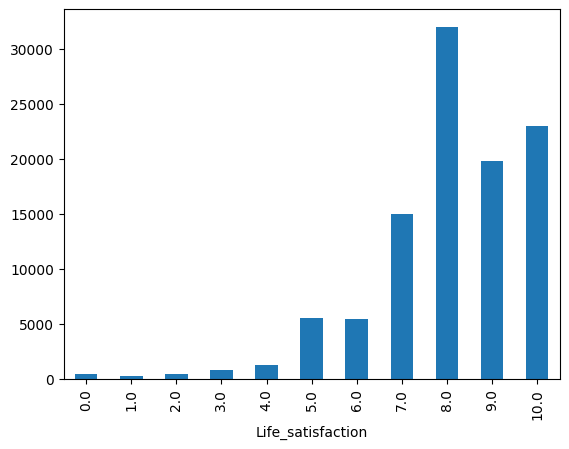

In [4]:
df["Life_satisfaction"].value_counts().sort_index().plot(kind="bar")

In [5]:
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Life_satisfaction"])
y = df["Life_satisfaction"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

with config_context(target_offload="auto") if 'config_context' in globals() else nullcontext():
    smote = SMOTETomek(n_jobs=-1, random_state=42)
    X_train_sample, y_train_sample = smote.fit_resample(X_train, y_train)

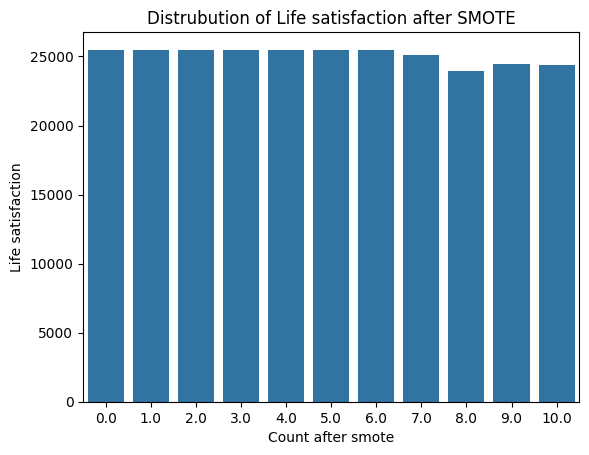

In [6]:
import seaborn as sns

sns.countplot(x=y_train_sample)
plt.xlabel("Count after smote")
plt.ylabel("Life satisfaction")
plt.title("Distrubution of Life satisfaction after SMOTE")
plt.show()

score for random guessing

In [7]:
from sklearn.metrics import mean_absolute_error

y_mean = np.full_like(y_test, np.mean(y_train_sample))
y_pred = np.clip(y_mean, 0, 10)
print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 3.258276928442143


score of logisticregression

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error

with config_context(target_offload="auto") if 'config_context' in globals() else nullcontext():
    clf = LogisticRegression(max_iter=1000, n_jobs=-1)
    clf.fit(X_train_sample, y_train_sample)
    y_pred = np.clip(clf.predict(X_test), 0, 10)
print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 1.5134784488972177


score of random forest

In [9]:
from sklearn.ensemble import RandomForestClassifier

with config_context(target_offload="auto") if 'config_context' in globals() else nullcontext():
    clf = RandomForestClassifier(n_jobs=-1, random_state=42)
    clf.fit(X_train_sample, y_train_sample)
    y_pred = np.clip(clf.predict(X_test), 0, 10)
print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 1.0887991927346115
